## Modelo Random Forest

Luego de realizar la selección de variables mediante LASSO, se propone la construcción de un modelo basado en Random Forest con el objetivo de predecir la decisión de realizar un swing frente a un lanzamiento. Este algoritmo permite modelar relaciones complejas entre las variables explicativas y la variable respuesta, ya que combina múltiples árboles de decisión y permite capturar relaciones no lineales e interacciones entre las características del lanzamiento.

Para la construcción del modelo se utilizaron las variables: `altura_zona`, `plate_x`, `plate_z`, `pitch_type`, `release_speed`, `balls` y `strikes`. Si bien LASSO permitió identificar efectos relevantes entre las variables, Random Forest no requiere incorporar manualmente términos de interacción, ya que estas relaciones son aprendidas automáticamente mediante las divisiones sucesivas realizadas en los árboles que conforman el modelo.

De esta manera, se busca evaluar la capacidad predictiva del modelo y analizar qué características del lanzamiento presentan mayor influencia en la decisión de realizar un swing.


In [28]:
# Cargamos los paquetes necesarios
import matplotlib.pyplot as plt 
import polars as pl
import seaborn as sns
import numpy as np
import pyprojroot
from plotnine import *
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score, 
    roc_curve,
    log_loss,
    f1_score
)
from sklearn.model_selection import train_test_split

In [ ]:
# Definir la ruta raiz del proyecto
ROOT = pyprojroot.here()

# Cargamos los datos
datos_entrenamiento = pl.read_parquet(ROOT / "datos" / "train.parquet")
datos_validacion = pl.read_parquet(ROOT / "datos" / "test.parquet")

# Convertimos a DataFrame de pandas
train_pd = datos_entrenamiento.to_pandas()
test_pd = datos_validacion.to_pandas()

In [5]:
# Variables seleccionadas por LASSO
variables = [
    "altura_zona",
    "plate_x",
    "plate_z",
    "pitch_type",
    "release_speed",
    "balls",
    "strikes"
]

A partir de las variables seleccionadas mediante LASSO, se definió el conjunto de variables explicativas utilizadas para el entrenamiento del modelo. La variable respuesta considerada fue `swing`, asociada a la decisión del bateador de realizar o no un movimiento frente al lanzamiento.

In [ ]:
# Se define la matriz X y el vector y para los datos de entrenamiento
X_train = train_pd[variables]
y_train = train_pd["swing"]

# Se define la matriz X y el vector y para los datos de validación
X_test = test_pd[variables]
y_test = test_pd["swing"]

Debido a que algunas variables utilizadas en el modelo presentan naturaleza categórica, como `pitch_type`, fue necesario realizar una transformación mediante variables indicadoras (dummies). Este procedimiento permite representar las categorías como variables numéricas que pueden ser interpretadas correctamente por el algoritmo.

In [ ]:
# Se convierten las variables categóricas a dummies para ambos conjuntos de datos
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [ ]:
# Nos aseguramos que los dos data sets tengan las mismas variables
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

### Entrenamiento del modelo

Para la construcción del modelo se utilizó un clasificador Random Forest, compuesto por un conjunto de árboles de decisión entrenados sobre diferentes muestras de los datos. 

En particular, la cantidad de árboles del modelo se fijó en 100 (`n_estimators` = 100), valor utilizado frecuentemente como configuración inicial en modelos Random Forest. Esta cantidad permite obtener una combinación suficientemente diversa de árboles para estabilizar las predicciones y reducir la variabilidad del modelo, manteniendo un costo computacional adecuado.

Además, se fijó una semilla aleatoria (`random_state` = 123) con el objetivo de garantizar la reproducibilidad de los resultados. 

Este algoritmo permite capturar relaciones no lineales entre las variables y aprender posibles interacciones sin necesidad de especificarlas previamente.

In [ ]:
# Se crea el modelo con Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=123
)

El modelo fue entrenado utilizando el conjunto de datos de entrenamiento, permitiendo que los árboles aprendan patrones asociados a la decisión de swing a partir de las variables seleccionadas.

In [ ]:
# Se ajusta el modelo
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",123
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

### Predicciones del modelo

Una vez entrenado el modelo, se realizaron predicciones sobre el conjunto de prueba, reservado previamente para evaluar el desempeño del modelo sobre datos no observados durante el entrenamiento. Estas predicciones corresponden a la clase estimada por el modelo para cada observación.

In [ ]:
# Se predicen los valores 
y_pred = rf.predict(X_test)

Además de la clasificación final, se obtuvieron las probabilidades predichas por el modelo para cada observación del conjunto de prueba. Estas probabilidades permiten evaluar el desempeño del modelo mediante métricas que consideran la confianza de las predicciones, como Log-loss y ROC-AUC.

In [ ]:
# Probabilidades predichas utilizando la partición de test
y_prob = rf.predict_proba(X_test)[:,1]

### Desempeño del modelo

A continuación, se evalúa la capacidad predictiva del modelo Random Forest mediante distintas métricas de desempeño. Se consideran medidas basadas tanto en las probabilidades estimadas por el modelo, como Log-loss y el área bajo la curva ROC (AUC), como métricas de clasificación obtenidas a partir de un umbral de decisión de 0.5.

In [18]:
# Evaluación del modelo

# Log-loss
logloss_rf = log_loss(
    y_test,
    y_prob
)

# Curva ROC
fpr, tpr, umbrales = roc_curve(
    y_test,
    y_prob
)

# AUC
auc = roc_auc_score(
    y_test,
    y_prob
)

El modelo obtuvo un Log-loss de aproximadamente 0.27, indicando que las probabilidades generadas por Random Forest presentan un buen nivel de ajuste respecto a las clases observadas. Al ser una métrica donde valores menores representan un mejor desempeño, este resultado sugiere que el modelo asigna probabilidades razonablemente confiables a sus predicciones.

Para complementar la evaluación, se analiza la curva ROC junto con el área bajo la curva (AUC), la cual permite medir la capacidad del modelo para distinguir entre las dos clases sin depender de un único punto de corte.

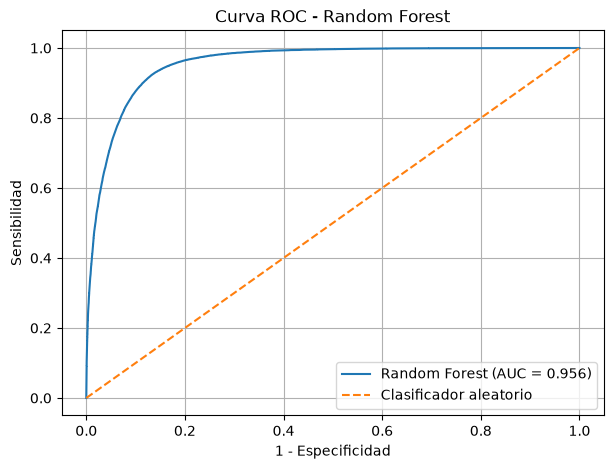

In [19]:
# Gráfico
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.3f})"
)

# Línea del clasificador aleatorio

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("1 - Especificidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.grid(True)

plt.show()

El modelo obtuvo un AUC de 0.956, lo que indica una excelente capacidad de discriminación entre las observaciones correspondientes a swing y no swing. Es decir, el resultado indica que Random Forest logra asignar probabilidades mayores a aquellos lanzamientos donde efectivamente ocurrió un swing, diferenciándolos adecuadamente de aquellos donde el bateador decidió no realizarlo. Esto evidencia que las variables seleccionadas mediante LASSO contienen información relevante para explicar la decisión de swing y que el modelo logra capturar patrones asociados a esta conducta.

Para obtener una clasificación final, se definió un umbral de decisión de 0.5 sobre las probabilidades predichas por el modelo. De esta manera, aquellas observaciones con una probabilidad mayor o igual a 0.5 fueron clasificadas como casos positivos (swing), mientras que las restantes fueron clasificadas como casos negativos (no swing).

In [20]:
# Clasificación usando umbral 0.5
predicciones = (y_prob >= 0.5).astype(int)

A partir de las clasificaciones obtenidas se construyó la matriz de confusión, la cual permite comparar las predicciones realizadas por el modelo con los valores reales observados. Esta matriz permite identificar aciertos y errores de clasificación mediante los valores de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

In [21]:
# Matriz de confusión
tn, fp, fn, tp = confusion_matrix(
    y_test,
    predicciones
).ravel()

A partir de los valores obtenidos de la matriz de confusión se calcularon diferentes métricas para analizar distintos aspectos del desempeño del modelo. 

In [22]:
# Métricas 
sensibilidad = tp / (tp + fn)
especificidad = tn / (tn + fp)
vpp = tp / (tp + fp)
vpn = tn / (tn + fn)

In [29]:
tabla_metricas_rf = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Sensibilidad",
        "Especificidad",
        "VPP",
        "VPN",
        "F1-SCORE"
    ],
    "Valor": [
        accuracy_score(y_test, predicciones),
        sensibilidad,
        especificidad,
        vpp,
        vpn,
        f1_score(y_test, predicciones)
    ]
})

tabla_metricas_rf

,Métrica,Valor
0,Accuracy,0.892929
1,Sensibilidad,0.908670
2,Especificidad,0.878713
3,VPP,0.871232
4,VPN,0.914190
5,F1-SCORE,0.889557


El modelo obtuvo un **Accuracy** de 0.893, indicando que aproximadamente el 89% de las observaciones fueron clasificadas correctamente. Por otro lado, la **sensibilidad** alcanzó un valor de 0.909, lo que muestra una alta capacidad del modelo para identificar correctamente aquellos lanzamientos donde efectivamente ocurrió un swing. Además, la **especificidad** fue de 0.879, indicando que el modelo también presenta un buen desempeño para reconocer los casos donde el bateador no realizó un swing. 

El **VPP** (valor predictivo positivo) fue de 0.871, mientras que el **VPN** (valor predictivo negativo) alcanzó 0.914, mostrando que las predicciones negativas presentan una mayor confiabilidad. Finalmente, el **F1-score** de 0.890 refleja un buen equilibrio entre la capacidad de detectar swings y la precisión de esas predicciones.

En conclusión, los resultados obtenidos muestran que el modelo presenta una buena capacidad predictiva para clasificar la ocurrencia de swings, logrando un desempeño equilibrado tanto en la detección de swings como en la identificación de aquellos lanzamientos donde no se realizó un swing. Las métricas obtenidas evidencian que el modelo es confiable y adecuado para este problema de clasificación.

### Importancia de las variables

Una de las ventajas de los modelos basados en árboles es la posibilidad de analizar la importancia relativa de las variables utilizadas durante el entrenamiento. Esta medida permite identificar cuáles características contribuyen en mayor medida a la capacidad predictiva del modelo.

In [16]:
# Importancia de las variables
importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias

,Variable,Importancia
0,altura_zona,4.747709e-01
1,plate_x,1.802149e-01
2,plate_z,1.772477e-01
3,release_speed,8.832894e-02
5,strikes,4.408058e-02
4,balls,2.001293e-02
11,pitch_type_FF,3.806802e-03
18,pitch_type_SL,2.583134e-03
17,pitch_type_SI,1.937730e-03
7,pitch_type_CU,1.864853e-03


Según la importancia obtenida, la variable con mayor influencia en la predicción fue `altura_zona`, seguida por `plate_x` y `plate_z`. Esto indica que la ubicación del lanzamiento dentro de la zona de strike presenta un papel fundamental en la decisión de realizar un swing.

En menor medida, variables asociadas a las características del lanzamiento como `release_speed`, `strikes` y `balls` también aportan información al modelo, aunque con una importancia inferior.

Por otro lado, las categorías individuales de `pitch_type` presentan importancias reducidas en comparación con las variables relacionadas con la ubicación del lanzamiento. Sin embargo, esto no implica que el tipo de lanzamiento no sea relevante, ya que Random Forest puede capturar su efecto en combinación con otras variables mediante las divisiones de los árboles.